## Extracting and Visualizing EEG Electrode Positions (10-05 System)

This notebook demonstrates how to extract and visualize standardized EEG electrode coordinates using the `eeg_positions` Python package.

We use the `get_elec_coords` function from `eeg_positions` to obtain 2D (x, y) coordinates and labels for all electrodes in the 10-05 system. The result is a dictionary with the following keys:
- 'x': list of x coordinates
- 'y': list of y coordinates
- 'z': list of z coordinates
- 'labels': electrode names

The `plot_coords` function is then used to visualize these electrode positions.

Output: The CSV file `global_electrode_positions.csv`, which is used in location-based channel embedding.

**Requirements:**
- Python 3.x
- `eeg_positions` package (install with `pip install eeg_positions`)


In [24]:
# !pip install eeg_positions

In [25]:
from eeg_positions import get_elec_coords, plot_coords
coords = get_elec_coords(
    system="1005",
    dim="2d",
)
coords
# this output is a dictionary with the following keys:
#   - 'x': list of x coordinates
#   - 'y': list of y coordinates
#   - 'z': list of z coordinates
#   - 'labels': electrode names

,label,x,y
0,Nz,0.000000,1.000000
1,T10,1.000000,0.000000
2,Iz,0.000000,-1.000000
3,T9,-1.000000,0.000000
4,Cz,0.000000,0.000000
...,...,...,...
343,POO6,0.244329,-0.631683
344,POO8h,0.286736,-0.638823
345,NAS,0.000000,1.000000
346,RPA,1.000000,0.000000


Now let's plot these coordinates.
We can supply some style arguments to :func:`eeg_positions.plot_coords` to control
the color of the electrodes and the text annotations.

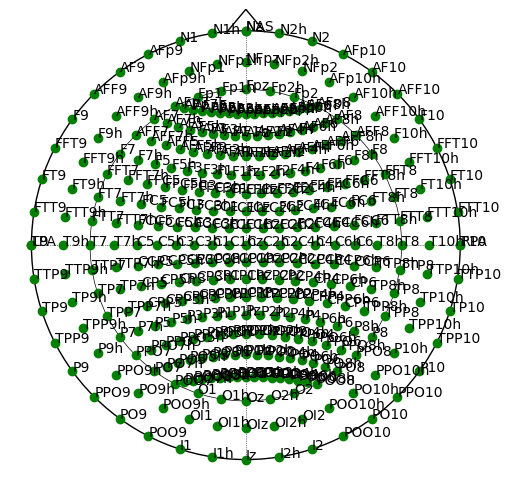

In [26]:
fig, ax = plot_coords(
    coords, scatter_kwargs={"color": "g"}, text_kwargs={"fontsize": 10}
)
plt.show()

Scaling the coordinates helps to **spread out** the electrode positions. This results in electrodes being **less clustered**, which improves **visualization** and makes the positions more suitable for **position-based channel embedding**.

In [29]:

coords['x'] = (coords['x']+0.8) *5
coords['y'] = (coords['y']+1)* 5


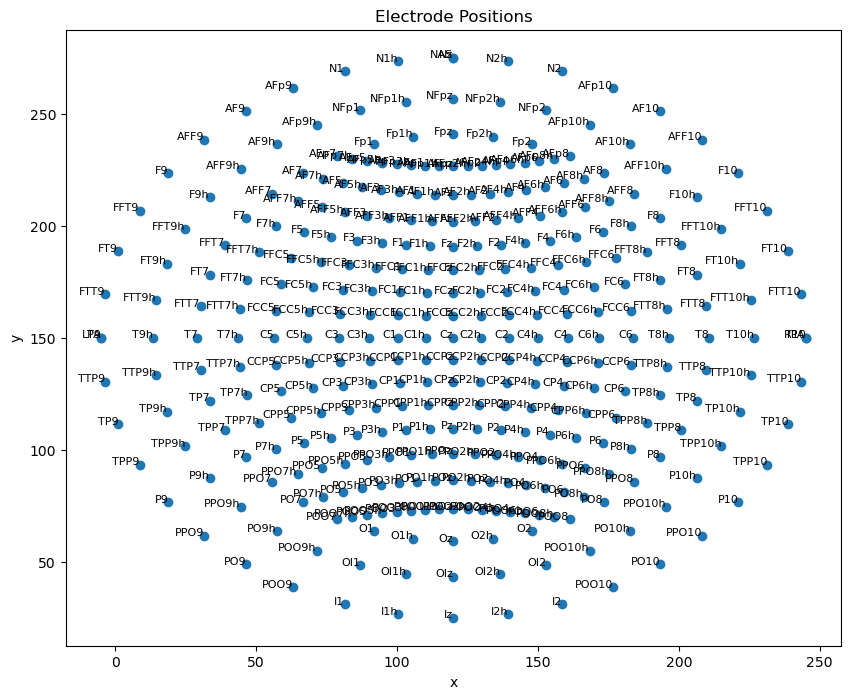

In [30]:
plt.figure(figsize=(10, 8))
plt.scatter(coords['x']*5, coords['y']*5)

for i, label in enumerate(coords['label']):
    plt.annotate(label, (coords['x'][i]*5, coords['y'][i]*5), fontsize=8, ha='right')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Electrode Positions')
plt.show()

In [31]:
# saving this coordinate for later use in EEG-X 
coords.to_csv("global_electrode_positions.csv", index=False)